In [1]:
import pandas as pd

df = pd.read_parquet('/kaggle/input/competitions/optiver-realized-volatility-prediction/book_train.parquet')

print(df.head())

   time_id  seconds_in_bucket  bid_price1  ask_price1  bid_price2  ask_price2  \
0        5                  0    1.001422    1.002301     1.00137    1.002353   
1        5                  1    1.001422    1.002301     1.00137    1.002353   
2        5                  5    1.001422    1.002301     1.00137    1.002405   
3        5                  6    1.001422    1.002301     1.00137    1.002405   
4        5                  7    1.001422    1.002301     1.00137    1.002405   

   bid_size1  ask_size1  bid_size2  ask_size2 stock_id  
0          3        226          2        100        0  
1          3        100          2        100        0  
2          3        100          2        100        0  
3          3        126          2        100        0  
4          3        126          2        100        0  


In [2]:
import pandas as pd
import numpy as np
!pip install hmmlearn
from hmmlearn import hmm

# calculate raw imbalance
df['queue_imbalance'] = df['bid_size1'] / (df['bid_size1'] + df['ask_size1'])
valid_mask = df['queue_imbalance'].notna()

#cap data at 50k to bypass single thread cpu limit
clean_df = df[valid_mask].iloc[:50000].copy()

train_data = []
chunk_lengths = []

#group chronologically to preserve the isolated time sequences
for time_id, group in clean_df.groupby('time_id', sort=False):
    obs = group['queue_imbalance'].values
    if len(obs) > 0:
        train_data.append(obs)
        chunk_lengths.append(len(obs))

X_train = np.concatenate(train_data).reshape(-1, 1)

print(f"Training and predicting safely on {len(X_train)} rows...\n")

#fit the 2-state model
model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=50, random_state=42)
model.fit(X_train, lengths=chunk_lengths)

# predict 
clean_df['hmm_state'] = model.predict(X_train, lengths=chunk_lengths)

print("--- HMM State Averages ---")
for i in range(2):
    state_mean = clean_df[clean_df['hmm_state'] == i]['queue_imbalance'].mean()
    print(f"State {i} Average Imbalance: {state_mean:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.0 MB/s eta 0:00:00
Training and predicting safely on 50000 rows...

--- HMM State Averages ---
State 0 Average Imbalance: 0.6265
State 1 Average Imbalance: 0.0332


In [3]:
mean_0 = clean_df[clean_df['hmm_state'] == 0]['queue_imbalance'].mean()
mean_1 = clean_df[clean_df['hmm_state'] == 1]['queue_imbalance'].mean()

if mean_0 > mean_1:
    calm_state = 0
    crash_state = 1
else:
    calm_state = 1
    crash_state = 0

print("\nDynamically Mapped Regimes")
print(f"Calm Market (State {calm_state}) Average Imbalance: {max(mean_0, mean_1):.4f}")
print(f"Buy-Side Vacuum (State {crash_state}) Average Imbalance: {min(mean_0, mean_1):.4f}")


Dynamically Mapped Regimes
Calm Market (State 0) Average Imbalance: 0.6265
Buy-Side Vacuum (State 1) Average Imbalance: 0.0332


In [4]:
print("Physical Server Load (Queue Backlog)")

# set up a simple list to map our dynamic variables to clean labels
regimes = [
    ("Calm Market", calm_state),
    ("Buy-Side Vacuum", crash_state)
]

for regime_name, state_id in regimes:
    # pull the data for whichever state id matches the current loop
    state_data = clean_df[clean_df['hmm_state'] == state_id]
    
    # calculate medians to prevent single-second extreme outliers from skewing the variance
    median_q_ask = state_data['ask_size1'].median()
    median_q_bid = state_data['bid_size1'].median()
    median_imbalance = state_data['queue_imbalance'].median()
    
    print(f"\n{regime_name} (Median Imbalance: {median_imbalance:.4f}):")
    print(f"Median Q_ask Backlog: {median_q_ask:.0f} shares")
    print(f"Median Q_bid Backlog: {median_q_bid:.0f} shares")
    
    # calculate the backlog multiplier to quantify the exact server failure
    if median_q_bid > 0:
        multiplier = median_q_ask / median_q_bid
        print(f"Queue Discrepancy: Q_ask is {multiplier:.2f}x larger than Q_bid")

Physical Server Load (Queue Backlog)

Calm Market (Median Imbalance: 0.5890):
Median Q_ask Backlog: 90 shares
Median Q_bid Backlog: 100 shares
Queue Discrepancy: Q_ask is 0.90x larger than Q_bid

Buy-Side Vacuum (Median Imbalance: 0.0206):
Median Q_ask Backlog: 100 shares
Median Q_bid Backlog: 2 shares
Queue Discrepancy: Q_ask is 50.00x larger than Q_bid


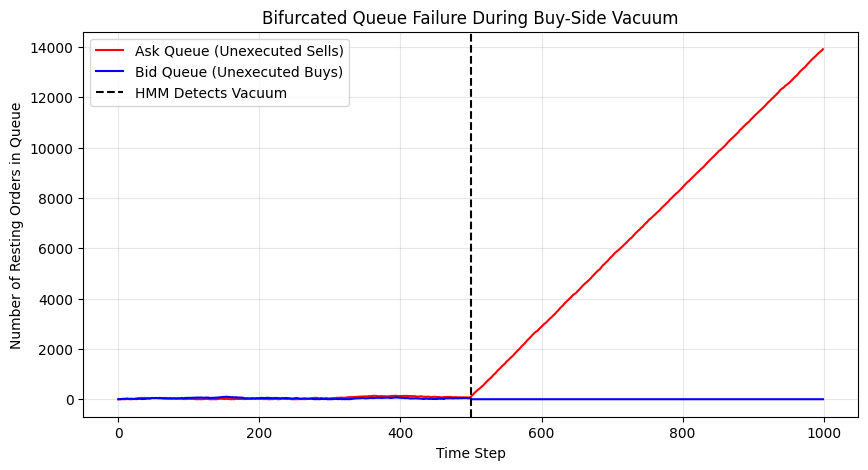

In [5]:
import numpy as np
import matplotlib.pyplot as plt

time_steps = 1000
midpoint = 500

q_ask = np.zeros(time_steps)
q_bid = np.zeros(time_steps)

np.random.seed(42)

for t in range(1, time_steps):
    if t < midpoint:
        # calm state flow
        lam_ask = np.random.poisson(10)
        mu_ask = np.random.poisson(10)
        
        lam_bid = np.random.poisson(10)
        mu_bid = np.random.poisson(10)
    else:
        # crash state buy-side vacuum
        lam_ask = np.random.poisson(30) 
        mu_ask = np.random.poisson(2)   
        
        lam_bid = np.random.poisson(1)  
        mu_bid = np.random.poisson(30)  

    q_ask[t] = max(0, q_ask[t-1] + lam_ask - mu_ask)
    q_bid[t] = max(0, q_bid[t-1] + lam_bid - mu_bid)

plt.figure(figsize=(10, 5))
plt.plot(q_ask, label="Ask Queue (Unexecuted Sells)", color="red")
plt.plot(q_bid, label="Bid Queue (Unexecuted Buys)", color="blue")

plt.axvline(x=midpoint, color="black", linestyle="--", label="HMM Detects Vacuum")

plt.title("Bifurcated Queue Failure During Buy-Side Vacuum")
plt.xlabel("Time Step")
plt.ylabel("Number of Resting Orders in Queue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

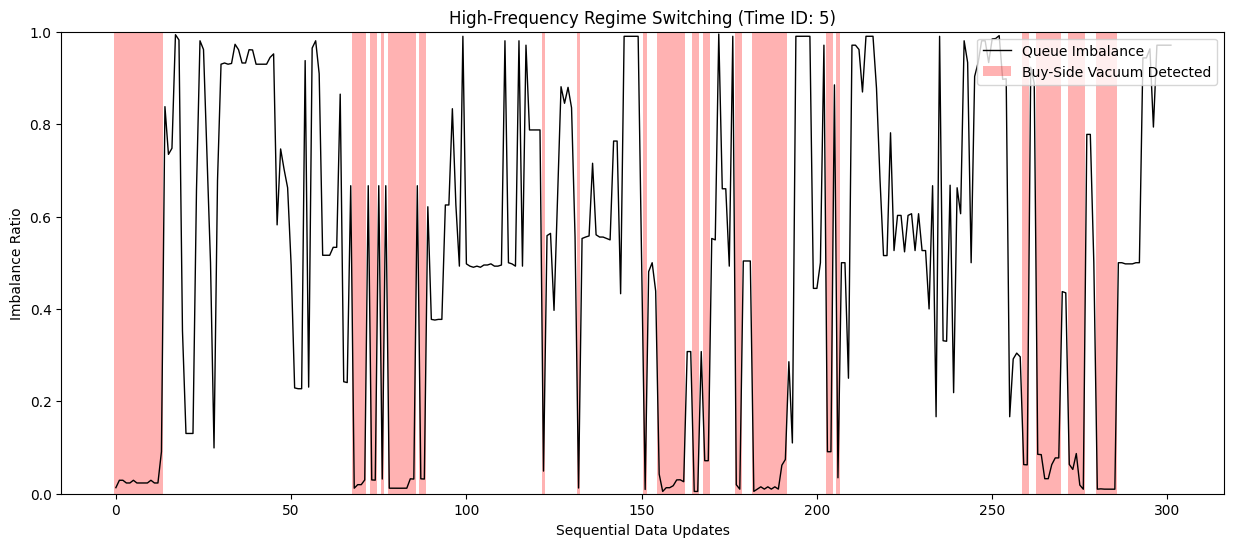

In [6]:
import matplotlib.pyplot as plt

# Isolate the very first 10-minute trading window from the cleaned data
sample_time_id = clean_df['time_id'].unique()[0]
plot_df = clean_df[clean_df['time_id'] == sample_time_id].copy()

time_steps = range(len(plot_df))
imbalance = plot_df['queue_imbalance'].values
states = plot_df['hmm_state'].values

plt.figure(figsize=(15, 6))
plt.plot(time_steps, imbalance, color='black', linewidth=1, label="Queue Imbalance")

# Shade the background red wherever the Viterbi algorithm detected the crash state
for t in time_steps:
    if states[t] == crash_state:
        plt.axvspan(t-0.5, t+0.5, color='red', alpha=0.3, lw=0)

plt.title(f"High-Frequency Regime Switching (Time ID: {sample_time_id})")
plt.xlabel("Sequential Data Updates")
plt.ylabel("Imbalance Ratio")
plt.ylim(0, 1)

# Clean up duplicate legend entries from the loop
handles, labels = plt.gca().get_legend_handles_labels()
from matplotlib.patches import Patch
handles.append(Patch(facecolor='red', alpha=0.3))
labels.append("Buy-Side Vacuum Detected")
plt.legend(handles, labels, loc='upper right')

plt.show()

In [7]:
import numpy as np

# pull the states from that exact same 10-minute window we just plotted
states = plot_df['hmm_state'].values

# calculate where the state toggles
state_changes = np.diff(states)
change_indices = np.where(state_changes != 0)[0] + 1

# add the start and end of the array to complete the boundaries
change_indices = np.insert(change_indices, 0, 0)
change_indices = np.append(change_indices, len(states))

vacuum_durations = []

# loop through the blocks and count how long the crash states lasted
for i in range(len(change_indices) - 1):
    start = change_indices[i]
    end = change_indices[i+1]
    current_state = states[start]
    
    if current_state == crash_state:
        duration = end - start
        vacuum_durations.append(duration)

# calculate the statistics of the crash durations
if len(vacuum_durations) > 0:
    mean_dur = np.mean(vacuum_durations)
    max_dur = np.max(vacuum_durations)
    var_dur = np.var(vacuum_durations, ddof=1)
    
    print(f"Total vacuum events detected: {len(vacuum_durations)}")
    print(f"Average vacuum duration: {mean_dur:.2f} ticks")
    print(f"Longest vacuum: {max_dur} ticks")
    print(f"Sample variance of duration: {var_dur:.2f}")
else:
    print("No vacuums detected in this specific window.")

Total vacuum events detected: 20
Average vacuum duration: 4.05 ticks
Longest vacuum: 14 ticks
Sample variance of duration: 13.42


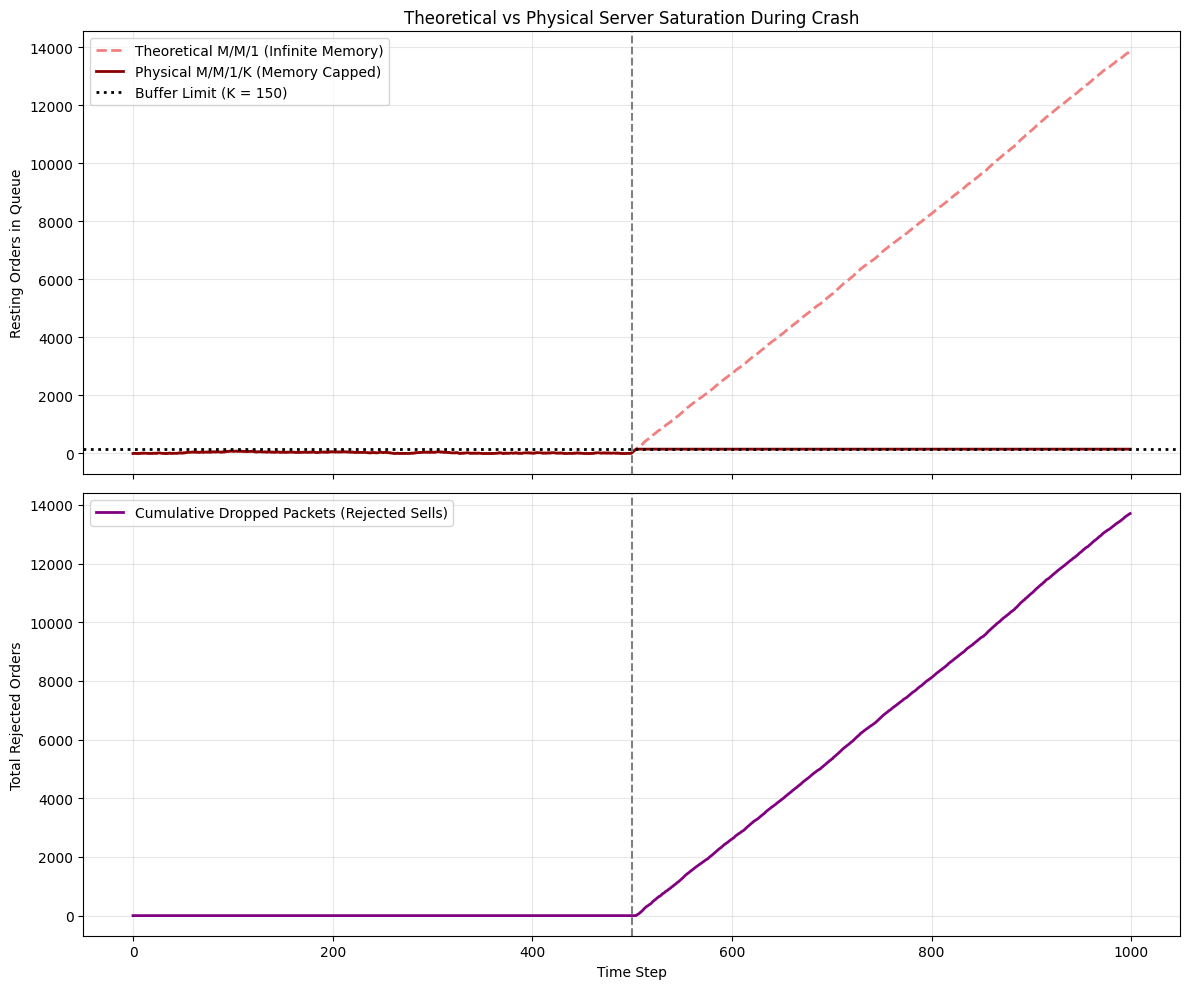

Server Buffer saturated 4 ticks after the liquidity vacuum started.
Total dropped sell orders: 13704


In [8]:
import numpy as np
import matplotlib.pyplot as plt

time_steps = 1000
midpoint = 500
K = 150  # server memory limit

q_ask_infinite = np.zeros(time_steps)
q_ask_finite = np.zeros(time_steps)
rejected_sells = np.zeros(time_steps)

np.random.seed(42)

# simulate exact same order flow hitting both theoretical and physical servers
for t in range(1, time_steps):
    if t < midpoint:
        lam_ask = np.random.poisson(10)
        mu_ask = np.random.poisson(10)
    else:
        lam_ask = np.random.poisson(30) 
        mu_ask = np.random.poisson(2)   

    # theoretical M/M/1 (infinite memory)
    q_ask_infinite[t] = max(0, q_ask_infinite[t-1] + lam_ask - mu_ask)
    
    # physical M/M/1/K (finite memory buffer)
    attempted_q = q_ask_finite[t-1] + lam_ask - mu_ask
    if attempted_q > K:
        rejected_sells[t] = attempted_q - K
        q_ask_finite[t] = K
    else:
        q_ask_finite[t] = max(0, attempted_q)

cum_rejected = np.cumsum(rejected_sells)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# plot 1: the queue divergence
ax1.plot(q_ask_infinite, label="Theoretical M/M/1 (Infinite Memory)", color="lightcoral", linestyle="--", linewidth=2)
ax1.plot(q_ask_finite, label="Physical M/M/1/K (Memory Capped)", color="darkred", linewidth=2)
ax1.axhline(y=K, color="black", linestyle=":", linewidth=2, label=f"Buffer Limit (K = {K})")
ax1.axvline(x=midpoint, color="grey", linestyle="--")
ax1.set_title("Theoretical vs Physical Server Saturation During Crash")
ax1.set_ylabel("Resting Orders in Queue")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# plot 2: the rejected orders
ax2.plot(cum_rejected, label="Cumulative Dropped Packets (Rejected Sells)", color="purple", linewidth=2)
ax2.axvline(x=midpoint, color="grey", linestyle="--")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Total Rejected Orders")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

saturation_step = np.where(q_ask_finite == K)[0]
if len(saturation_step) > 0:
    first_sat = saturation_step[0]
    print(f"Server Buffer saturated {first_sat - midpoint} ticks after the liquidity vacuum started.")
    print(f"Total dropped sell orders: {int(cum_rejected[-1])}")